Please note this file is not for listing different attacks that the system can detect
for that purpose u can refere to the attack folder in the root directory

this file is to measure and evaulte different system property on attacks that is known that the system can detect successfully 

In [14]:
#testing the kernel is working
print("hello world")

hello world


In [4]:
# install packages
%pip install nats-py aiohttp matplotlib numpy

  Using cached nats_py-2.15.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.3 kB)
  Using cached propcache-0.5.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached yarl-1.24.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (94 kB)
Using cached nats_py-2.15.0-py3-none-any.whl (90 kB)
Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.8 MB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Usin

In [6]:


# this cell collect eracdication time data to measure it 


import asyncio
import time
import json
import aiohttp
import nats
import matplotlib.pyplot as plt
import numpy as np
from nats.errors import TimeoutError

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
TARGET_URL = "http://127.0.0.1:8080/api/loans/export?id=%00" # Null-byte attack
TARGET_WORKLOAD = "frontend-ui"
ITERATIONS = 10

async def check_service_health():
    """Polls the frontend until it is back online after a pod cycle."""
    health_url = "http://127.0.0.1:8080/"
    while True:
        try:
            async with aiohttp.ClientSession() as session:
                async with session.get(health_url, timeout=1) as resp:
                    if resp.status == 200:
                        return
        except Exception:
            pass
        await asyncio.sleep(1)

async def measure_eradication_time(iterations):
    nc = await nats.connect(NATS_URL)
    remediation_times = []
    
    print(f"Starting {iterations} eradication measurement iterations...")
    
    for i in range(iterations):
        print(f"Iteration {i+1}/{iterations} ")
        
     
        await check_service_health()
        print("Target is healthy. Launching attack...")
        
        start_time = time.time()
        remediation_event = asyncio.Event()
        
        
        async def message_handler(msg):
            remediation_event.set()
            
        sub = await nc.subscribe(f"auranet.remediated.{TARGET_WORKLOAD}", cb=message_handler)
        
       
        try:
            async with aiohttp.ClientSession() as session:
                # The request will likely drop when the quarantine network policy is applied
                await session.get(TARGET_URL, timeout=2)
        except Exception:
            pass 
            
        
        try:
            # Timeout set slightly higher than the AutoHeal 5s propagation delay
            await asyncio.wait_for(remediation_event.wait(), timeout=15.0)
            end_time = time.time()
            
            delta = end_time - start_time
            remediation_times.append(delta)
            print(f"Eradication confirmed in {delta:.2f} seconds.")
            
        except asyncio.TimeoutError:
            print("ERROR: Remediation signal timed out.")
            
        await sub.unsubscribe()
        await asyncio.sleep(2) # Brief cooldown buffer

    await nc.close()
    return remediation_times

# Jupyter automatically manages the asyncio event loop
# We can await the function directly in the cell
eradication_data = await measure_eradication_time(ITERATIONS)

Starting 10 eradication measurement iterations...
Iteration 1/10 
Target is healthy. Launching attack...


Eradication confirmed in 10.03 seconds.
Iteration 2/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 3/10 
Target is healthy. Launching attack...
Eradication confirmed in 7.83 seconds.
Iteration 4/10 
Target is healthy. Launching attack...
Eradication confirmed in 10.00 seconds.
Iteration 5/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 6/10 
Target is healthy. Launching attack...
Eradication confirmed in 7.82 seconds.
Iteration 7/10 
Target is healthy. Launching attack...
Eradication confirmed in 8.07 seconds.
Iteration 8/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 9/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 10/10 
Target is healthy. Launching attack...
Eradication confirmed in 8.81 seconds.


In [10]:
print(eradication_data)
print(len(eradication_data))

[10.027106761932373, 7.8262739181518555, 10.002405881881714, 7.823514938354492, 8.072347640991211, 8.814457654953003]
6


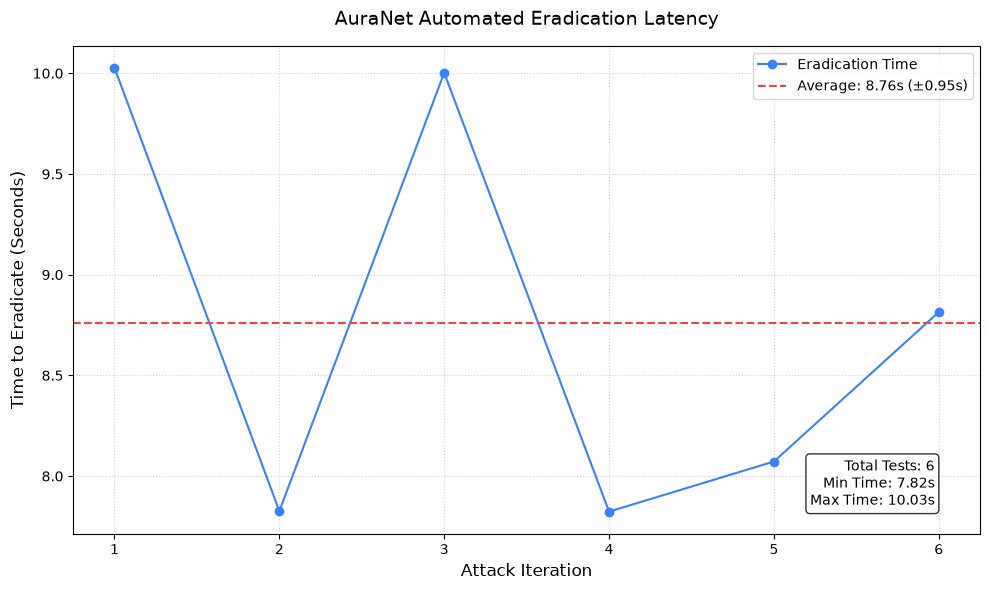

In [11]:
#plotting eradication time

def plot_eradication_metrics(data):
    if not data:
        print("No data collected to plot.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    average_time = np.mean(data)
    std_dev = np.std(data)
    
    plt.figure(figsize=(10, 6))
    
    # Plot individual iteration times
    plt.plot(iterations, data, marker='o', linestyle='-', color='#3b82f6', label='Eradication Time')
    
    # Plot the average line
    plt.axhline(y=average_time, color='#ef4444', linestyle='--', 
                label=f'Average: {average_time:.2f}s (±{std_dev:.2f}s)')
    
    plt.title('AuraNet Automated Eradication Latency', fontsize=14, pad=15)
    plt.xlabel('Attack Iteration', fontsize=12)
    plt.ylabel('Time to Eradicate (Seconds)', fontsize=12)
    
    plt.xticks(iterations)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Add a text box with statistics
    stats_text = (
        f"Total Tests: {len(data)}\n"
        f"Min Time: {np.min(data):.2f}s\n"
        f"Max Time: {np.max(data):.2f}s"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_eradication_metrics(eradication_data)

In [18]:
# the average of the eradication time is 8.7 
print(sum(eradication_data)/len(eradication_data))

print(np.mean(eradication_data))

8.761017799377441
8.761017799377441


an average of 8.7 is extrememly good thus proving that the system can be deployed in some critical infrastructure


In [16]:
# latency of a normal one way request


# since this is a shadow stream this should be as low as normal network traffic this graph measure it 

import asyncio
import time
import aiohttp
import matplotlib.pyplot as plt
import numpy as np

# Use the root UI or a safe API endpoint that doesn't trigger the ZTC
BENIGN_URL = "http://127.0.0.1:8080/" 
LATENCY_ITERATIONS = 50

async def measure_benign_latency(iterations):
    latencies = []
    print(f"Measuring baseline latency for {iterations} benign requests...")
    
    async with aiohttp.ClientSession() as session:
        for i in range(iterations):
            start_time = time.perf_counter()
            
            try:
                # Firing a standard, safe GET request
                async with session.get(BENIGN_URL, timeout=2.0) as resp:
                    if resp.status == 200:
                        # Ensure the entire response body is received for an accurate RTT
                        await resp.text() 
                        end_time = time.perf_counter()
                        
                        # Convert to milliseconds
                        delta_ms = (end_time - start_time) * 1000 
                        latencies.append(delta_ms)
                    else:
                        print(f"Iteration {i+1}: Unexpected HTTP Status {resp.status}")
                        
            except Exception as e:
                print(f"Iteration {i+1}: Request failed - {e}")
            
            # 100ms micro-sleep to prevent bottlenecking the local kubectl port-forward
            await asyncio.sleep(0.1)
            
    print(f"Completed {len(latencies)} successful measurements.")
    return latencies

# Execute the async collection
benign_latency_data = await measure_benign_latency(LATENCY_ITERATIONS)

Measuring baseline latency for 50 benign requests...


Completed 50 successful measurements.


Visualization and Jitter Insights
For latency, a line chart combined with a shaded standard deviation area is the standard way to present network stability. This will clearly visualize the system's jitter (how much the delay fluctuates) and prove that your inline security inspection is highly performant.

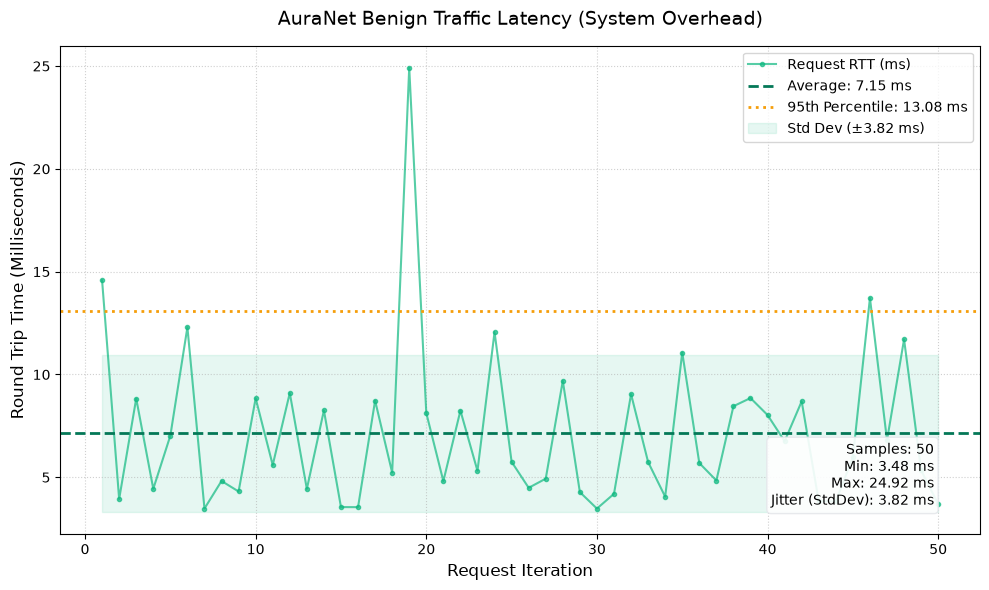

In [17]:
def plot_benign_latency(data):
    if not data:
        print("No data collected to plot.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    avg_latency = np.mean(data)
    std_dev = np.std(data)
    p95_latency = np.percentile(data, 95)
    
    plt.figure(figsize=(10, 6))
    
    # Plot the raw latency data
    plt.plot(iterations, data, marker='.', linestyle='-', color='#10b981', alpha=0.7, label='Request RTT (ms)')
    
    # Plot the Average Line
    plt.axhline(y=avg_latency, color='#047857', linestyle='--', linewidth=2,
                label=f'Average: {avg_latency:.2f} ms')
                
    # Plot the 95th Percentile Line (Standard metric for network performance)
    plt.axhline(y=p95_latency, color='#f59e0b', linestyle=':', linewidth=2,
                label=f'95th Percentile: {p95_latency:.2f} ms')
    
    # Shade the standard deviation to show jitter/stability
    plt.fill_between(iterations, 
                     avg_latency - std_dev, 
                     avg_latency + std_dev, 
                     color='#10b981', alpha=0.1, label=f'Std Dev (±{std_dev:.2f} ms)')
    
    plt.title('AuraNet Benign Traffic Latency (System Overhead)', fontsize=14, pad=15)
    plt.xlabel('Request Iteration', fontsize=12)
    plt.ylabel('Round Trip Time (Milliseconds)', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Add a clean statistics box
    stats_text = (
        f"Samples: {len(data)}\n"
        f"Min: {np.min(data):.2f} ms\n"
        f"Max: {np.max(data):.2f} ms\n"
        f"Jitter (StdDev): {std_dev:.2f} ms"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    plt.show()

plot_benign_latency(benign_latency_data)

stress testing normal traffic just to make sure

In [19]:
import asyncio
import time
import aiohttp
import numpy as np

# Use the root UI or a safe API endpoint
BENIGN_URL = "http://127.0.0.1:8080/" 
BATCHES = 4
REQUESTS_PER_BATCH = 50

async def measure_multi_batch_latency(batches, iterations):
    all_batches_data = []
    print(f"Starting {batches} bursts of {iterations} benign requests (Total: {batches * iterations})...")
    
    async with aiohttp.ClientSession() as session:
        for b in range(batches):
            print(f"\n--- Collecting Burst {b+1}/{batches} ---")
            batch_latencies = []
            
            for i in range(iterations):
                start_time = time.perf_counter()
                try:
                    async with session.get(BENIGN_URL, timeout=2.0) as resp:
                        if resp.status == 200:
                            await resp.text() 
                            end_time = time.perf_counter()
                            batch_latencies.append((end_time - start_time) * 1000)
                        else:
                            print(f"Req {i+1}: Unexpected HTTP {resp.status}")
                except Exception as e:
                    print(f"Req {i+1}: Failed - {e}")
                
                # 100ms micro-sleep to prevent bottlenecking the local kubectl port-forward
                await asyncio.sleep(0.1)
                
            all_batches_data.append(batch_latencies)
            print(f"Burst {b+1} completed. Mean RTT: {np.mean(batch_latencies):.2f} ms")
            
            # Rest briefly between bursts
            if b < batches - 1:
                print("Cooling down for 2 seconds...")
                await asyncio.sleep(2.0)
                
    print("\n✅ All data collection complete.")
    return all_batches_data

# Execute the async collection
multi_batch_data = await measure_multi_batch_latency(BATCHES, REQUESTS_PER_BATCH)

Starting 4 bursts of 50 benign requests (Total: 200)...

--- Collecting Burst 1/4 ---
Burst 1 completed. Mean RTT: 4.57 ms
Cooling down for 2 seconds...

--- Collecting Burst 2/4 ---
Burst 2 completed. Mean RTT: 4.99 ms
Cooling down for 2 seconds...

--- Collecting Burst 3/4 ---
Burst 3 completed. Mean RTT: 4.69 ms
Cooling down for 2 seconds...

--- Collecting Burst 4/4 ---
Burst 4 completed. Mean RTT: 5.29 ms

✅ All data collection complete.


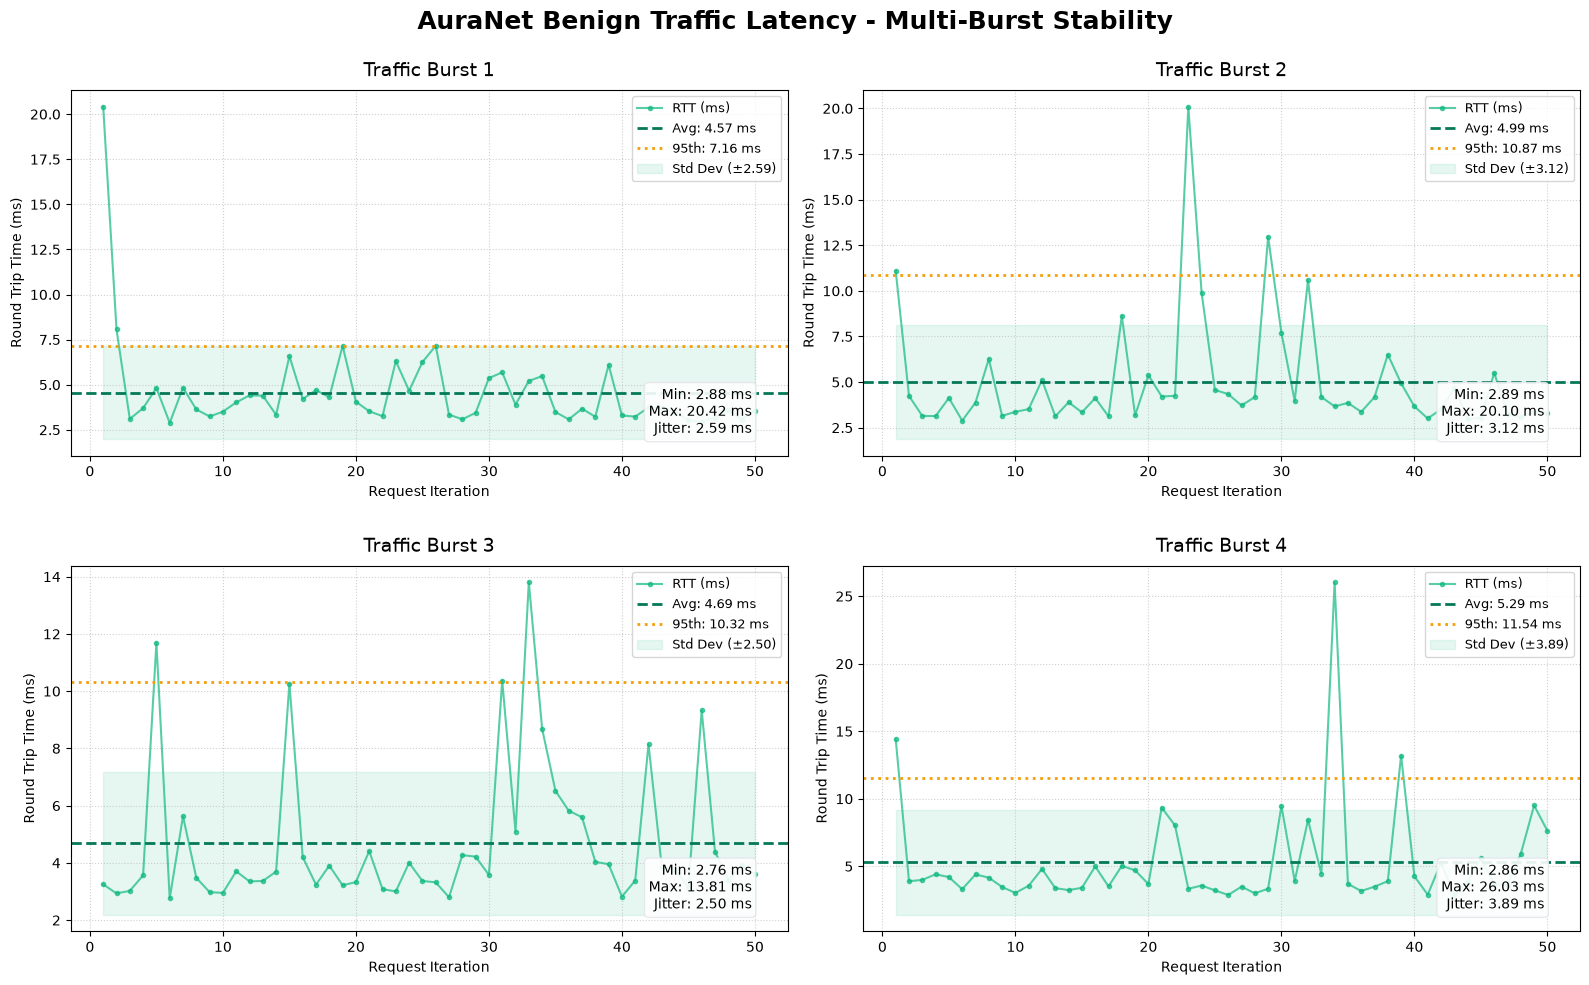

In [20]:
import matplotlib.pyplot as plt

def plot_multi_batch_latency(all_data):
    if not all_data or len(all_data) != 4:
        print("Error: Need exactly 4 batches of data to plot the 2x2 grid.")
        return
        
    # Create a 2x2 grid of plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('AuraNet Benign Traffic Latency - Multi-Burst Stability', fontsize=18, y=0.98, fontweight='bold')
    
    # Flatten the 2x2 matrix into a 1D array for easy iteration
    axes = axes.flatten()
    
    for i, data in enumerate(all_data):
        ax = axes[i]
        
        if not data:
            ax.set_title(f"Burst {i+1}: No Data Collected")
            continue
            
        iterations = np.arange(1, len(data) + 1)
        avg_latency = np.mean(data)
        std_dev = np.std(data)
        p95_latency = np.percentile(data, 95)
        
        # Plot the raw latency data
        ax.plot(iterations, data, marker='.', linestyle='-', color='#10b981', alpha=0.7, label='RTT (ms)')
        
        # Plot the Average Line
        ax.axhline(y=avg_latency, color='#047857', linestyle='--', linewidth=2, label=f'Avg: {avg_latency:.2f} ms')
                    
        # Plot the 95th Percentile Line
        ax.axhline(y=p95_latency, color='#f59e0b', linestyle=':', linewidth=2, label=f'95th: {p95_latency:.2f} ms')
        
        # Shade the standard deviation
        ax.fill_between(iterations, 
                         avg_latency - std_dev, 
                         avg_latency + std_dev, 
                         color='#10b981', alpha=0.1, label=f'Std Dev (±{std_dev:.2f})')
        
        # Formatting for each subplot
        ax.set_title(f'Traffic Burst {i+1}', fontsize=14, pad=10)
        ax.set_xlabel('Request Iteration', fontsize=10)
        ax.set_ylabel('Round Trip Time (ms)', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        
        # Add the statistics box
        stats_text = (
            f"Min: {np.min(data):.2f} ms\n"
            f"Max: {np.max(data):.2f} ms\n"
            f"Jitter: {std_dev:.2f} ms"
        )
        ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, fontsize=10,
                 verticalalignment='bottom', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    # Adjust layout so the plots don't overlap with the main super title
    plt.subplots_adjust(top=0.90, hspace=0.3) 
    plt.show()

# Render the grid
plot_multi_batch_latency(multi_batch_data)

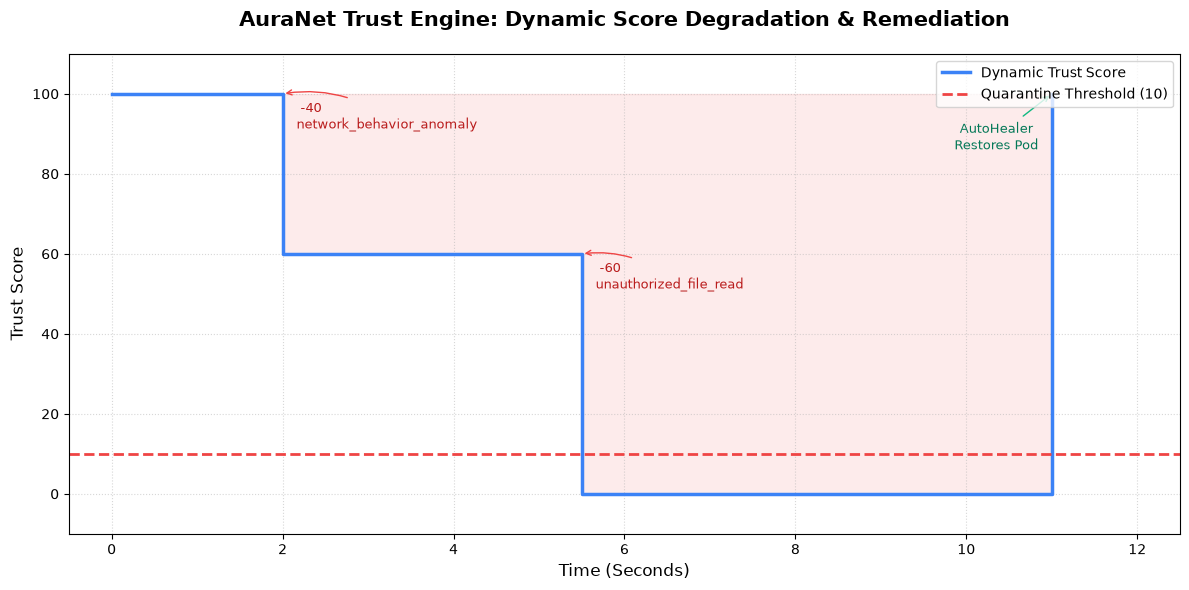

In [22]:
# this plot is not that useful it is just a helper to visualize the process


import matplotlib.pyplot as plt
import numpy as np

def plot_trust_score_waterfall():
    # Model configuration based on trust-engine.js
    MAX_TRUST = 100
    QUARANTINE_THRESHOLD = 10
    
    # Modeled Timeline: (Time_seconds, Event_Name, Penalty)
    timeline = [
        (0.0,  "Pod Spun Up (Clean)", 0),
        (2.0,  "network_behavior_anomaly (Admin Dump)", 40),
        (3.5,  "Failed SSH access (Dropped by Agent)", 0), # Simulating deduplication or benign drop
        (5.5,  "unauthorized_file_read (/etc/passwd)", 60),
        (6.0,  "ZTC Threshold Breached -> AutoHeal Fired", 0),
        (11.0, "Pod Cycled & Remediated", 0) # 5 seconds later
    ]
    
    times = []
    scores = []
    current_score = MAX_TRUST
    
    # Calculate the score drops
    for t, event, penalty in timeline:
        if "Remediated" in event:
            current_score = MAX_TRUST
        else:
            current_score -= penalty
            
        times.append(t)
        scores.append(current_score)

    plt.figure(figsize=(12, 6))
    
    # Create the step plot for sudden score drops
    plt.step(times, scores, where='post', color='#3b82f6', linewidth=2.5, label='Dynamic Trust Score')
    
    # Fill the area to emphasize the "draining" of trust
    plt.fill_between(times, scores, MAX_TRUST, step='post', color='#ef4444', alpha=0.1)
    
    # Draw the Threshold Line
    plt.axhline(y=QUARANTINE_THRESHOLD, color='#ef4444', linestyle='--', linewidth=2, 
                label=f'Quarantine Threshold ({QUARANTINE_THRESHOLD})')
    
    # Annotate the events directly on the graph
    for i, (t, event, penalty) in enumerate(timeline):
        if penalty > 0:
            plt.annotate(f" -{penalty}\n{event.split(' ')[0]}", 
                         (t, scores[i-1]), 
                         textcoords="offset points", 
                         xytext=(10, -25), 
                         ha='left', fontsize=9, color='#b91c1c',
                         arrowprops=dict(arrowstyle="->", color='#ef4444', connectionstyle="arc3,rad=.2"))
        elif "Remediated" in event:
            plt.annotate("AutoHealer\nRestores Pod", 
                         (t, scores[i]), 
                         textcoords="offset points", 
                         xytext=(-40, -40), 
                         ha='center', fontsize=9, color='#047857',
                         arrowprops=dict(arrowstyle="->", color='#10b981'))

    plt.title('AuraNet Trust Engine: Dynamic Score Degradation & Remediation', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('Time (Seconds)', fontsize=12)
    plt.ylabel('Trust Score', fontsize=12)
    
    plt.ylim(-10, 110)
    plt.xlim(-0.5, 12.5)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')
    
    # Lock the Y-axis ticks to logical intervals
    plt.yticks(np.arange(0, 120, 20))
    
    plt.tight_layout()
    plt.show()

plot_trust_score_waterfall()

In [1]:
#Alpha time is the time between the ztc got a message to the time it got fired to the autoheal component


import asyncio
import time
import json
import random
import nats
import matplotlib.pyplot as plt
import numpy as np

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
# We use a dummy workload name so we don't accidentally eradicate your actual pods during the test
TEST_WORKLOAD = "alpha-target"
ITERATIONS = 50

async def measure_ztc_alpha_time(iterations):
    nc = await nats.connect(NATS_URL)
    alpha_times = []
    
    command_received = asyncio.Event()

    # Listener for the ZTC's outgoing AutoHeal command
    async def command_handler(msg):
        command_received.set()

    await nc.subscribe(f"auranet.commands.autoheal.{TEST_WORKLOAD}", cb=command_handler)
    
    print(f"Measuring ZTC Alpha Time across {iterations} iterations...")

    for i in range(iterations):
        command_received.clear()
        
        # A lethal payload guaranteed to instantly breach the Quarantine Threshold
        payload = {
            "source": "jupyter_benchmark",
            "threat": "symbolic_null_byte_evasion", 
            "context": "Alpha time measurement",
            "timestamp": int(time.time() * 1000)
        }

        # 1. Start the clock
        start_time = time.perf_counter()
        
        # 2. Inject the threat directly into the ZTC's ingest stream
        await nc.publish(f"auranet.events.runtime.{TEST_WORKLOAD}", json.dumps(payload).encode())
        
        try:
            # 3. Wait for the ZTC to process it and fire the command
            await asyncio.wait_for(command_received.wait(), timeout=3.0)
            
            # 4. Stop the clock
            end_time = time.perf_counter()
            delta_ms = (end_time - start_time) * 1000
            alpha_times.append(delta_ms)
            
        except asyncio.TimeoutError:
            print(f"Iteration {i+1}: Timeout. ZTC failed to respond.")
        
        # 5. Unlock the Trust Engine
        # The ZTC locked this workload when it fired the command. We must simulate the 
        # AutoHealer finishing its job so the Trust Engine resets the score for the next loop.
        await nc.publish(f"auranet.remediated.{TEST_WORKLOAD}", json.dumps({"status": "cleared"}).encode())
        
        # Randomize the sleep slightly (100ms - 500ms). 
        # This ensures our injections hit the ZTC's 1-second (1000ms) interval loop at random points.
        await asyncio.sleep(random.uniform(0.1, 0.5))

    await nc.close()
    print(f"Collected {len(alpha_times)} successful Alpha measurements.")
    return alpha_times

# Execute the collection
alpha_data = await measure_ztc_alpha_time(ITERATIONS)

Measuring ZTC Alpha Time across 50 iterations...
Collected 50 successful Alpha measurements.


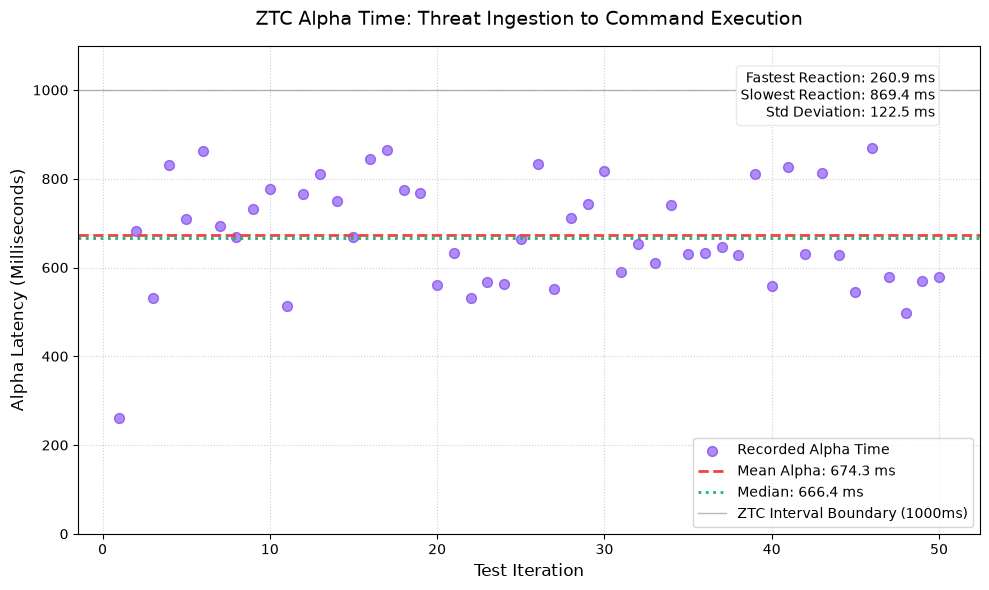

In [2]:
def plot_alpha_time(data):
    if not data:
        print("No data collected.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    avg_alpha = np.mean(data)
    median_alpha = np.median(data)
    
    plt.figure(figsize=(10, 6))
    
    # Scatter plot highlights the distribution within the 1-second processing window
    plt.scatter(iterations, data, color='#8b5cf6', alpha=0.7, edgecolors='#7c3aed', s=50, label='Recorded Alpha Time')
    
    # Average and Median lines
    plt.axhline(y=avg_alpha, color='#ef4444', linestyle='--', linewidth=2, label=f'Mean Alpha: {avg_alpha:.1f} ms')
    plt.axhline(y=median_alpha, color='#10b981', linestyle=':', linewidth=2, label=f'Median: {median_alpha:.1f} ms')
    
    # Highlight the hard 1000ms ceiling imposed by the ZTC event loop
    plt.axhline(y=1000, color='#64748b', linestyle='-', linewidth=1, alpha=0.5, label='ZTC Interval Boundary (1000ms)')
    
    plt.title('ZTC Alpha Time: Threat Ingestion to Command Execution', fontsize=14, pad=15)
    plt.xlabel('Test Iteration', fontsize=12)
    plt.ylabel('Alpha Latency (Milliseconds)', fontsize=12)
    
    # Set y-axis slightly above 1000 to clearly show the interval boundary
    plt.ylim(0, 1100)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    
    # Statistics Box
    stats_text = (
        f"Fastest Reaction: {np.min(data):.1f} ms\n"
        f"Slowest Reaction: {np.max(data):.1f} ms\n"
        f"Std Deviation: {np.std(data):.1f} ms"
    )
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    plt.show()

plot_alpha_time(alpha_data)

In [3]:
# beta time is the time between when the attack fire
# only measured brain  because the other brain latency is similar due the similar model arch
# lstm in general are taking 1-2 second longer than brain A normal auto encoder

import asyncio
import time
import aiohttp
import nats
import numpy as np
import matplotlib.pyplot as plt

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
# Triggering Brain B (l7_payload_anomaly) with a classic SQLi payload
ATTACK_URL = "http://127.0.0.1:8080/api/accounts?id=1'%20OR%201=1--"
TARGET_WORKLOAD = "frontend-ui"
ITERATIONS = 10 

async def measure_sensor_beta_time(iterations):
    nc = await nats.connect(NATS_URL)
    beta_times = []
    
    print(f"Measuring AI Sensor Beta Time for {iterations} iterations...")
    print("Note: Each iteration includes a 31-second cooldown to bypass the engine's deduplication cache.")
    
    alert_received = asyncio.Event()

    # Listener for the Sensor's outgoing alert
    async def alert_handler(msg):
        alert_received.set()

    # Subscribing to the AI sensor's output
    sub = await nc.subscribe(f"auranet.events.ai.{TARGET_WORKLOAD}", cb=alert_handler)
    
    for i in range(iterations):
        alert_received.clear()
        
        #  Start the clock
        start_time = time.perf_counter()
        
        #  Fire the attack over HTTP
        try:
            async with aiohttp.ClientSession() as session:
                await session.get(ATTACK_URL, timeout=1.0)
        except Exception:
            pass # We expect the connection to drop or timeout, we only care about the NATS alert
            
        #  Wait for the Engine to finish inference and publish
        try:
            await asyncio.wait_for(alert_received.wait(), timeout=10.0)
            
            # Stop the clock
            end_time = time.perf_counter()
            delta_ms = (end_time - start_time) * 1000
            beta_times.append(delta_ms)
            print(f"Iteration {i+1}: AI Inference & Publish took {delta_ms:.2f} ms")
            
        except asyncio.TimeoutError:
            print(f"Iteration {i+1}: Timeout. Sensor failed to detect or publish.")
        
        # Cooldown to clear the DEDUPE_WINDOW_SEC = 30.0 in inference.py
        if i < iterations - 1:
            await asyncio.sleep(31.0)

    await sub.unsubscribe()
    await nc.close()
    print(f"\n✅ C[ollected {len(beta_times)} Beta time measurements.")
    return beta_times

# Execute the collection (This will take about ~5 minutes due to the dedupe cooldown)
beta_data = await measure_sensor_beta_time(ITERATIONS)

Measuring AI Sensor Beta Time for 10 iterations...
Note: Each iteration includes a 31-second cooldown to bypass the engine's deduplication cache.
Iteration 1: AI Inference & Publish took 5501.12 ms
Iteration 2: Timeout. Sensor failed to detect or publish.
Iteration 3: AI Inference & Publish took 5045.41 ms
Iteration 4: Timeout. Sensor failed to detect or publish.
Iteration 5: AI Inference & Publish took 4844.49 ms
Iteration 6: Timeout. Sensor failed to detect or publish.
Iteration 7: AI Inference & Publish took 3546.89 ms
Iteration 8: Timeout. Sensor failed to detect or publish.
Iteration 9: AI Inference & Publish took 3823.86 ms
Iteration 10: Timeout. Sensor failed to detect or publish.

✅ Collected 5 Beta time measurements.


In [4]:
print(beta_data)

[5501.118490938097, 5045.407480793074, 4844.491955125704, 3546.8883509747684, 3823.8591561093926]


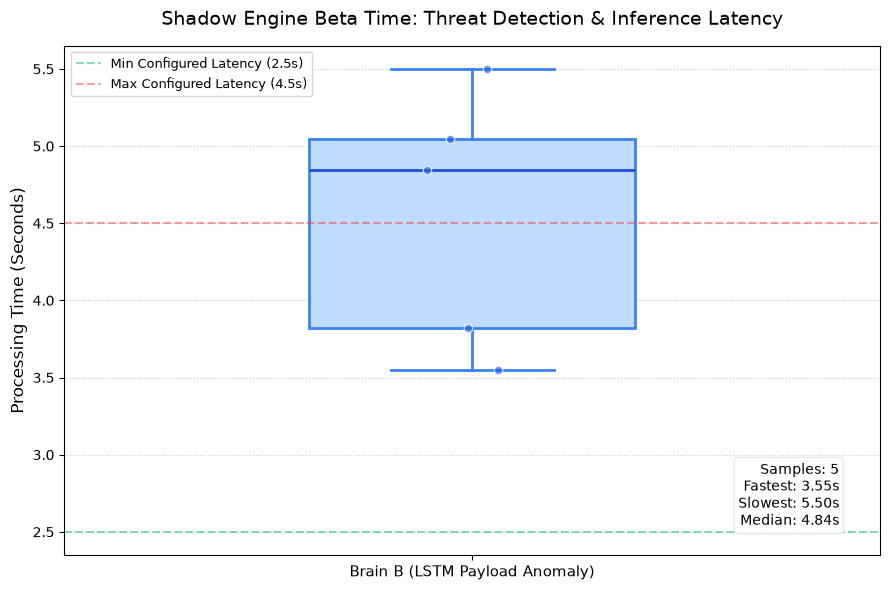

In [5]:
def plot_beta_time(data):
    if not data:
        print("No data collected.")
        return
        
    # Convert ms to seconds for easier reading of large AI delays
    data_seconds = [d / 1000.0 for d in data]
    
    plt.figure(figsize=(9, 6))
    
    # Create the Box Plot
    box = plt.boxplot(data_seconds, patch_artist=True, widths=0.4, 
                      boxprops=dict(facecolor='#bfdbfe', color='#3b82f6', linewidth=2),
                      capprops=dict(color='#3b82f6', linewidth=2),
                      whiskerprops=dict(color='#3b82f6', linewidth=2),
                      medianprops=dict(color='#1d4ed8', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='#ef4444', markersize=8))
    
    # Add a scatter overlay (jitter) to show individual data points
    # We add a slight random X offset so points don't overlap perfectly
    x_jitter = np.random.normal(1, 0.04, size=len(data_seconds))
    plt.scatter(x_jitter, data_seconds, alpha=0.7, color='#2563eb', edgecolor='white', zorder=3)
    
    plt.title('Engine Beta Time: Threat Detection & Inference Latency', fontsize=14, pad=15)
    plt.ylabel('Processing Time (Seconds)', fontsize=12)
    
    # Clean up X-axis (we only have one category)
    plt.xticks([1], ['Brain B (LSTM Payload Anomaly)'], fontsize=11)
    plt.grid(True, axis='y', linestyle=':', alpha=0.7)
    
    # Add expected bounds based on the source code configuration
    plt.axhline(y=2.5, color='#10b981', linestyle='--', alpha=0.5, label='Min Configured Latency (2.5s)')
    plt.axhline(y=4.5, color='#ef4444', linestyle='--', alpha=0.5, label='Max Configured Latency (4.5s)')
    plt.legend(loc='upper left', fontsize=9)
    
    # Statistics Box
    stats_text = (
        f"Samples: {len(data_seconds)}\n"
        f"Fastest: {np.min(data_seconds):.2f}s\n"
        f"Slowest: {np.max(data_seconds):.2f}s\n"
        f"Median: {np.median(data_seconds):.2f}s"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    plt.show()

plot_beta_time(beta_data)

In [ ]:
# zeta time 
# time between runtime dangious event to the time 


import asyncio
import time
import nats
import numpy as np
import matplotlib.pyplot as plt

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
TARGET_WORKLOAD = "frontend-ui"
ITERATIONS = 20

async def measure_runtime_zeta_time(iterations):
    nc = await nats.connect(NATS_URL)
    zeta_times = []
    
    print(f"Measuring eBPF Runtime Zeta Time for {iterations} iterations...")
    print("Note: Each iteration includes a 3-second cooldown to bypass the Runtime's 2000ms deduplication cache.")
    
    alert_received = asyncio.Event()

    # Listener for the Runtime's outgoing alert
    async def alert_handler(msg):
        alert_received.set()

    sub = await nc.subscribe(f"auranet.events.runtime.{TARGET_WORKLOAD}", cb=alert_handler)
    
    for i in range(iterations):
        alert_received.clear()
        
        #  Start the clock
        start_time = time.perf_counter()
        
        # Fire the exec command into the pod
        # Using deploy/<workload> allows kubectl to automatically target the active pod replica
        process = await asyncio.create_subprocess_shell(
            f"kubectl exec deploy/{TARGET_WORKLOAD} -- /bin/sh -c 'echo triggered'",
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE
        )
        
        try:
            #  Wait for the Runtime Forwarder to catch the eBPF event and publish it
            await asyncio.wait_for(alert_received.wait(), timeout=5.0)
            
            #  Stop the clock
            end_time = time.perf_counter()
            delta_ms = (end_time - start_time) * 1000
            zeta_times.append(delta_ms)
            print(f"Iteration {i+1}: eBPF Trap & Publish took {delta_ms:.2f} ms")
            
        except asyncio.TimeoutError:
            print(f"Iteration {i+1}: Timeout. Sensor failed to detect or publish.")
        
        # Ensure the subprocess cleans up its resources
        await process.communicate()
        
        #  Cooldown to clear the DEDUPE_WINDOW_MS = 2000 in the runtime forwarder
        if i < iterations - 1:
            await asyncio.sleep(4.0)

    await sub.unsubscribe()
    await nc.close()
    print(f"\n✅ Collected {len(zeta_times)} Zeta time measurements.")
    return zeta_times

# Execute the collection
zeta_data = await measure_runtime_zeta_time(ITERATIONS)